# Romlig analyse av skoler og kollektiv i Kristiansand sentrum

Denne notebooken analyserer tilgjengeligheten til skoler og busstopp i Kristiansand sentrum.

Vi undersøker:
- Hvor mange skoler som finnes i området
- Hvor mange som ligger innenfor 500 meter fra busstopp
- Hvordan de er geografisk fordelt

Vi bruker:
- OpenStreetMap (API via OSMnx)
- GeoPandas for analyse
- DuckDB for databasekrav
- Rasteranalyse dokumentert via CLI

## Installasjon av nødvendige pakker

Denne cellen installerer alle nødvendige Python-pakker direkte i notebooken.

In [1]:
!pip install osmnx geopandas matplotlib pandas shapely pyproj duckdb

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


## Import av biblioteker

Vi importerer bibliotekene som brukes i analysen.

In [2]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box
import duckdb

plt.rcParams["figure.figsize"] = (10, 10)

ox.settings.use_cache = True

## Definere studieområde

Vi definerer en bounding box rundt Kristiansand sentrum.

In [3]:
bbox = (7.97, 58.135, 8.02, 58.155)  # (west, south, east, north)

## Hente data fra OpenStreetMap

Vi henter:
- skoler
- busstopp

In [4]:
schools = ox.features_from_bbox(bbox, {"amenity": "school"})
bus_stops = ox.features_from_bbox(bbox, {"highway": "bus_stop"})

schools = gpd.GeoDataFrame(schools, geometry="geometry", crs="EPSG:4326")
bus_stops = gpd.GeoDataFrame(bus_stops, geometry="geometry", crs="EPSG:4326")

print("Antall skoler:", len(schools))
print("Antall busstopp:", len(bus_stops))

Antall skoler: 10
Antall busstopp: 67


## Kontroll av data

Vi sjekker at datasettene faktisk inneholder data.

In [5]:
schools.head()

geometry amenity capacity  \
element id                                                      
node    5613219663  POINT (7.99373 58.14964)  school      105   
        5826541621  POINT (7.98881 58.14771)  school      NaN   
        5826541622  POINT (7.99224 58.14584)  school      NaN   
        6482120515  POINT (8.00215 58.14656)  school      NaN   
        6482755095  POINT (8.00261 58.14833)  school      NaN   

                                         email  fee grades isced:level  \
element id                                                               
node    5613219663          post@samfundet.org  yes   5-10         1;2   
        5826541621                         NaN  NaN    NaN         NaN   
        5826541622                         NaN  yes    NaN           3   
        6482120515  vennesla.vgs@oasenskole.no  yes  11-13           3   
        6482755095                         NaN  yes  11-13           3   

                                                             name  \
element id                                                          
node    5613219663                       Samfundets skole Sentrum   
        5826541621  Noroff School of Technology and Digital Media   
        5826541622                            Sonans Kristiansand   
        6482120515                       Oasen videregående skole   
        6482755095                                 Lev bibelskole   

                                       operator operator:type  ...  \
element id                                                     ...   
node    5613219663  Samfundets skole Sentrum AS       private  ...   
        5826541621                          NaN           NaN  ...   
        5826541622                          NaN       private  ...   
        6482120515  Oasen videregående skole AS       private  ...   
        6482755095               Lev bibelskole       private  ...   

                   ssr:stedsnr ssr:type                 website  check_date  \
element id                                                                    
node    5613219663      167996    skole   https://samfundet.org         NaN   
        5826541621         NaN      NaN  https://www.noroff.no/         NaN   
        5826541622         NaN      NaN                     NaN  2025-07-04   
        6482120515         NaN      NaN     https://oasenvgs.no         NaN   
        6482755095         NaN      NaN                     NaN         NaN   

                   wikidata wikipedia alt_name building ref:bygningsnr  \
element id                                                               
node    5613219663      NaN       NaN      NaN      NaN            NaN   
        5826541621      NaN       NaN      NaN      NaN            NaN   
        5826541622      NaN       NaN      NaN      NaN            NaN   
        6482120515      NaN       NaN      NaN      NaN            NaN   
        6482755095      NaN       NaN      NaN      NaN            NaN   

                   start_date  
element id                     
node    5613219663        NaN  
        5826541621        NaN  
        5826541622        NaN  
        6482120515        NaN  
        6482755095        NaN  

[5 rows x 22 columns]

In [6]:
bus_stops.head()

geometry bench  bin  bus   highway  lit  \
element id                                                                    
node    602732450    POINT (7.99126 58.1468)   yes  yes  yes  bus_stop  yes   
        602732451   POINT (7.99157 58.14696)   yes  yes  yes  bus_stop  NaN   
        602732454   POINT (7.99077 58.14654)   yes  yes  yes  bus_stop  yes   
        1241328039  POINT (8.00896 58.15212)   yes  yes  yes  bus_stop  NaN   
        1458051994    POINT (8.01176 58.149)   NaN  NaN  NaN  bus_stop  NaN   

                                          name public_transport  ref ref:nsrq  \
element id                                                                      
node    602732450   Henrik Wergelands gate (D)         platform    D    38799   
        602732451   Henrik Wergelands gate (E)         platform    E    38804   
        602732454   Henrik Wergelands gate (C)         platform    C    38798   
        1241328039               Lund Torv (A)         platform    A    41293   
        1458051994              Høivold brygge              NaN  NaN    39900   

                   shelter tactile_paving official_name  
element id                                               
node    602732450      yes             no           NaN  
        602732451      yes            NaN           NaN  
        602732454      yes            yes           NaN  
        1241328039     yes            NaN           NaN  
        1458051994     NaN            NaN           NaN

## Visualisering av data

Vi plotter skoler og busstopp.

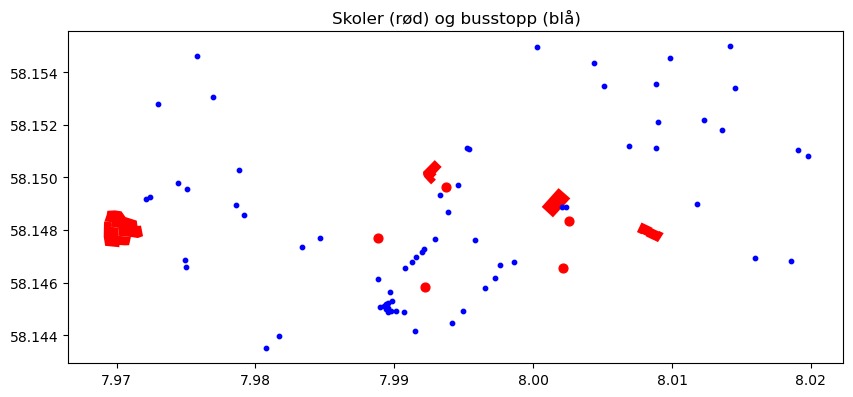

In [9]:
fig, ax = plt.subplots()

# sett lik skala (VIKTIG!)
ax.set_aspect('equal')

schools.plot(ax=ax, color="red", markersize=40)
bus_stops.plot(ax=ax, color="blue", markersize=10)

ax.set_title("Skoler (rød) og busstopp (blå)")

plt.show()

## Transformasjon til metrisk koordinatsystem

For å kunne lage buffere i meter må vi konvertere dataene fra geografiske koordinater (grader) til et projisert koordinatsystem (meter). Vi bruker UTM sone 32N (EPSG:32632).

In [11]:
schools = schools.to_crs(epsg=32632)
bus_stops = bus_stops.to_crs(epsg=32632)

## Bufferanalyse

Vi lager en buffersone på 500 meter rundt alle busstopp. Dette representerer et område som er innenfor gangavstand til kollektivtransport.

In [12]:
bus_buffer = bus_stops.buffer(500)
bus_buffer = gpd.GeoDataFrame(geometry=bus_buffer, crs=bus_stops.crs)

print("Antall bufferområder:", len(bus_buffer))

Antall bufferområder: 67


## Overlay-analyse

Vi undersøker hvilke skoler som ligger innenfor 500 meter fra et busstopp ved hjelp av en romlig join.

In [13]:
schools_in_buffer = gpd.sjoin(schools, bus_buffer, predicate="intersects")

print("Skoler innenfor 500 meter:", len(schools_in_buffer))

Skoler innenfor 500 meter: 154


## Visualisering av bufferanalyse

Kartet viser:
- Alle skoler (rød)
- Skoler innenfor buffer (grønn)
- Bufferområder (transparent)

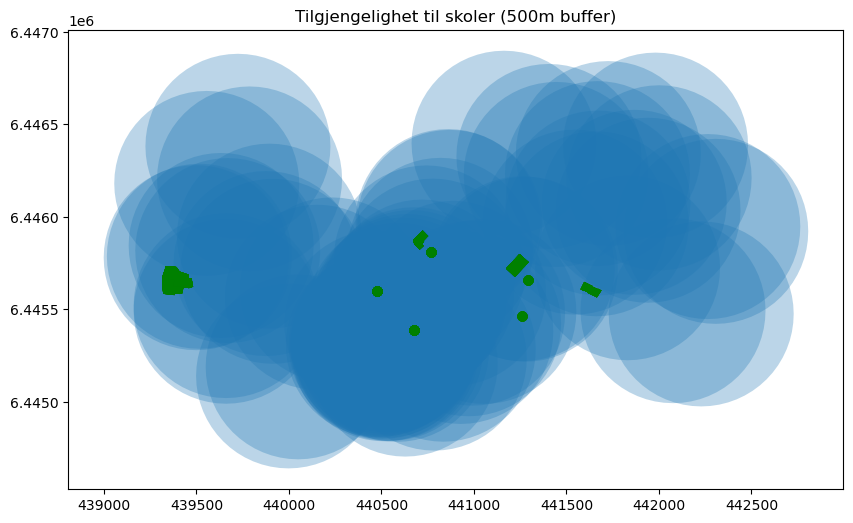

In [14]:
fig, ax = plt.subplots()

ax.set_aspect('equal')

# Buffer
bus_buffer.plot(ax=ax, alpha=0.3)

# Alle skoler
schools.plot(ax=ax, color="red", markersize=40)

# Skoler innenfor buffer
schools_in_buffer.plot(ax=ax, color="green", markersize=40)

ax.set_title("Tilgjengelighet til skoler (500m buffer)")

plt.show()

## Opprette et rutenett (grid)

For å analysere fordelingen av skoler lager vi et rutenett over studieområdet. Hver rute er 500 x 500 meter.

In [15]:
xmin, ymin, xmax, ymax = schools.total_bounds

grid_size = 500  # meter
cells = []

x = xmin
while x < xmax:
    y = ymin
    while y < ymax:
        cells.append(box(x, y, x + grid_size, y + grid_size))
        y += grid_size
    x += grid_size

grid = gpd.GeoDataFrame(geometry=cells, crs=schools.crs)

print("Antall ruter:", len(grid))

Antall ruter: 10


## Telle antall skoler per rute

Vi bruker en romlig join for å telle hvor mange skoler som ligger i hver rute.

In [17]:
join = gpd.sjoin(schools, grid, predicate="intersects")

counts = join.groupby("index_right").size()

grid["school_count"] = counts
grid["school_count"] = grid["school_count"].fillna(0)

## Visualisering av resultat

Kartet viser antall skoler per rute.

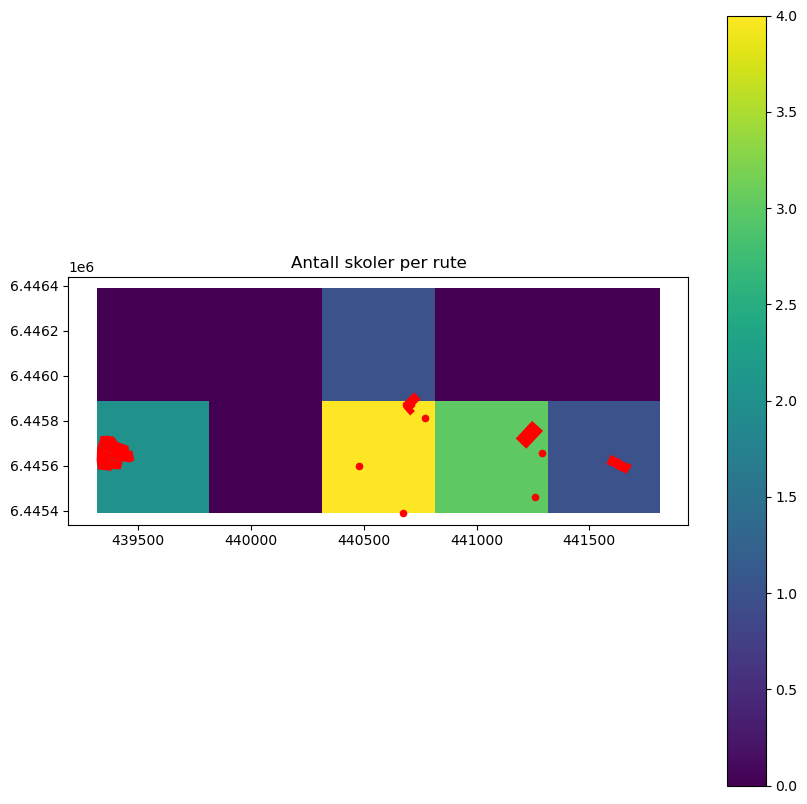

In [19]:
fig, ax = plt.subplots()

ax.set_aspect('equal')

grid.plot(
    column="school_count",
    ax=ax,
    legend=True
)

schools.plot(ax=ax, color="red", markersize=20)

ax.set_title("Antall skoler per rute")

plt.show()

## Bruk av DuckDB

For å oppfylle kravet om bruk av Pandas, GeoPandas, PostGIS eller DuckDB brukes DuckDB til å kjøre en enkel SQL-spørring på skoledatasettet.

Dette viser hvordan geografiske data også kan behandles i en database-lignende arbeidsflyt.

In [20]:
import duckdb

## Registrere GeoDataFrame i DuckDB

Vi registrerer skoledatasettet i DuckDB slik at det kan spørres med SQL.

In [24]:
con = duckdb.connect()

# Fjern geometry-kolonnen
schools_df = schools.drop(columns="geometry")

# Registrer i DuckDB
con.register("schools", schools_df)

# SQL-spørring
result = con.execute("""
SELECT COUNT(*) AS antall_skoler
FROM schools
""").fetchdf()

result

,antall_skoler
0,10


## SQL-spørring på skoledatasettet

Her teller vi hvor mange skoler som finnes i datasettet ved hjelp av SQL.

In [25]:
result = con.execute("""
SELECT COUNT(*) AS antall_skoler
FROM schools
""").fetchdf()

result

,antall_skoler
0,10


## Rasteranalyse

Rasteranalysen dokumenteres med kommandolinjeverktøy fra GDAL. Målet er å laste ned et høydedatasett (DEM), beregne helning (slope), filtrere ut bratte områder over 30 grader, konvertere resultatet til vektordata og lage to hillshade-varianter.

Denne delen viser den planlagte arbeidsflyten for rasteranalyse.

## Rasteranalyse (GDAL)

Følgende kommandoer brukes for rasteranalyse:

### Lag slope
```bash
gdaldem slope kristiansand.tif slope.tif

### Filtrer >30 grader
```bash
gdaldem slope kristiansand.tif slope.tif

### Polygonize
```bash
gdal_polygonize.py slope_gt30.tif slope.geojson

### Hillshade
```bash
gdaldem hillshade kristiansand.tif hillshade1.tif
gdaldem hillshade kristiansand.tif hillshade2.tif -az 315 -alt 45


---

# 🧱 7. AVSLUTNING

```markdown
## Oppsummering

Denne notebooken har vist en full arbeidsflyt for romlig analyse i Python. Data ble hentet fra OpenStreetMap via API, analysert med GeoPandas og videre undersøkt med buffer, overlay og romlig aggregering. I tillegg ble DuckDB brukt til SQL-baserte spørringer på datasettet.

Rasterdelen ble dokumentert som en planlagt GDAL-basert arbeidsflyt for beregning av slope, polygonisering av bratte områder og produksjon av hillshade.